In [34]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.compose import  ColumnTransformer



## Loading Dataset

In [2]:
df = pd.read_csv('used_cars.csv')
df.sample(2)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
3992,Toyota,Sequoia SR5,2010,"154,860 mi.",Gasoline,310.0HP 4.6L 8 Cylinder Engine Gasoline Fuel,6-Speed A/T,Silver,Gray,None reported,Yes,"$17,900"
3364,Land,Rover Range Rover Velar P380 SE R-Dynamic,2019,"19,813 mi.",Gasoline,380.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,8-Speed A/T,Silver,Beige,None reported,Yes,"$51,900"


## Finding missing values and shape

In [3]:
print('Shape:', df.shape)
print('\nMissing values:\n', df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().any())
print('\nData types:\n', df.dtypes)

Shape: (4009, 12)

Missing values:
 brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

Duplicate rows: False

Data types:
 brand             str
model             str
model_year      int64
milage            str
fuel_type         str
engine            str
transmission      str
ext_col           str
int_col           str
accident          str
clean_title       str
price             str
dtype: object


## Checking missing columns values

In [4]:
missing_cols = ['fuel_type', 'accident', 'clean_title']
for col in missing_cols:
    print(f'\n {col}')
    print(df[col].value_counts(dropna=False))



 fuel_type
fuel_type
Gasoline          3309
Hybrid             194
NaN                170
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64

 accident
accident
None reported                             2910
At least 1 accident or damage reported     986
NaN                                        113
Name: count, dtype: int64

 clean_title
clean_title
Yes    3413
NaN     596
Name: count, dtype: int64


## Filling missing column

In [5]:
df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode()[0])
df['accident'] = df['accident'].fillna(df['accident'].mode()[0])
df['clean_title'] = df['clean_title'].fillna('Unknown')


## Replacing data types with float

In [6]:
df['milage'] =(
    df['milage'].str.replace(',','',regex=False).str.replace('mi.','',regex=False).astype(float)
)
df['price'] =(
    df['price'].str.replace('$','',regex=False).str.replace(',','',regex=False).astype(float)
)

## Detecting outlier

In [7]:
df['price'].quantile([0.90, 0.95, 0.99])

0.90     79999.00
0.95    111600.00
0.99    272713.28
Name: price, dtype: float64

## Fixing Outlier 

In [8]:
upper_cap = df['price'].quantile(0.95)
df = df[df['price']<=upper_cap].copy()
print(f"Rows remaining: {len(df)}, price cap: {upper_cap:.0f}")

Rows remaining: 3808, price cap: 111600


## Feature engineering

In [30]:
#In engine Column 
df['horsepower'] = df['engine'].str.extract(r'(\d+(?:\d+\.\d+)?)HP').astype(float)

df['engine_capacity'] = df['engine'].str.extract(r'(\d+(?:\.\d+)?)L').astype(float)

df['cylinders'] = df['engine'].str.extract(r'(?:[VI](\d+)|(\d+)\s*Cylinder)',
                                           expand=False).bfill(axis=1).iloc[:, 0].astype(float)
df['is_turbo'] = df['engine'].str.contains('Turbo', case=False, na=False).astype(int)

#In transmission column
df['is_automatic'] = df['transmission'].str.contains('A/T|Automatic', case=False, na=False).astype(int)

#Making new column
df['car_age'] = 2026 - df['model_year']


## Filling missing values which we got in feature engineering

In [10]:
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())
df['engine_capacity'] = df['engine_capacity'].fillna(df['engine_capacity'].median())
df['cylinders'] = df['cylinders'].fillna(df['cylinders'].median())


## Making X and y column

In [31]:
features = [
    'brand', 'model', 'model_year', 'milage', 'fuel_type',
        'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
        'horsepower', 'engine_capacity' , 'cylinders' , 'is_turbo' , 'car_age', 'is_automatic'
]
X = df[features]
y = df['price']

## Splitting Data

In [32]:
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=22)

## Frequency encoding for high cardinality

In [33]:
high_cardinality_cols = ['ext_col','int_col','model']
for col in high_cardinality_cols:
    frequency = X_train[col].value_counts()
    X_train[col] = X_train[col].map(frequency).astype(int)
    X_test[col] = X_test[col].map(frequency).fillna(0).astype(int)

In [14]:
OHE = OneHotEncoder(handle_unknown='ignore')


## Model Training

In [15]:
Categorical_col = ['brand','fuel_type','transmission','accident','clean_title']
Numer_col = [ 'model_year', 'milage', 'model', 'ext_col', 'int_col', 'horsepower', 
             'engine_capacity', 'cylinders', 'is_turbo', 'is_automatic', 'car_age' ]

In [16]:
T1 = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', Numer_col) ,
        ('cat', OHE, Categorical_col)

    ]
)

In [17]:
RFR = RandomForestRegressor()

In [18]:
pipeline = Pipeline([
    ('preprocesssor' ,T1),
    ('model', RFR)
])

In [19]:
X_train.dtypes



brand                  str
model                int64
model_year           int64
milage             float64
fuel_type              str
transmission           str
ext_col              int64
int_col              int64
accident               str
clean_title            str
horsepower         float64
engine_capacity    float64
cylinders          float64
is_turbo             int64
car_age              int64
is_automatic         int64
dtype: object

In [20]:
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesssor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['brand','model','model_year',...,'is_turbo','car_age','is_automatic']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [21]:
y_pred = pipeline.predict(X_test)

In [22]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2 Score: {r2:.2f}')

MAE: 6307.23
MSE: 95643786.45
RMSE: 9779.76
R2 Score: 0.81


## Visualization

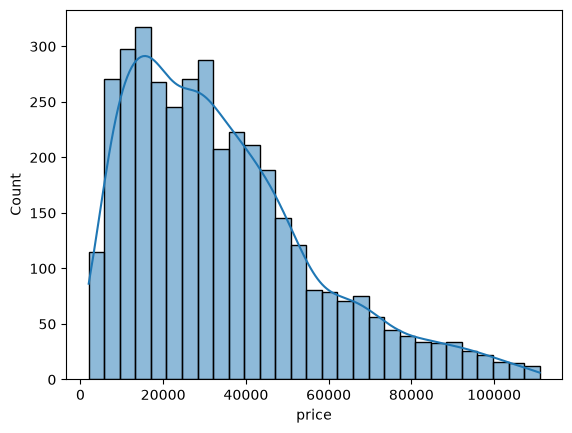

In [23]:
sns.histplot(df['price'],kde=True)
plt.show()

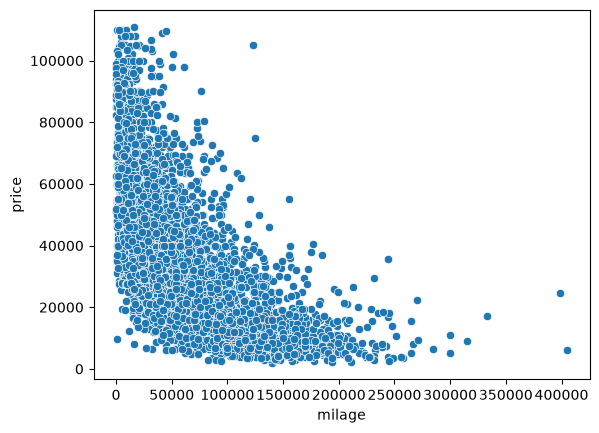

In [24]:
sns.scatterplot(data=df, x='milage', y='price')
plt.show()

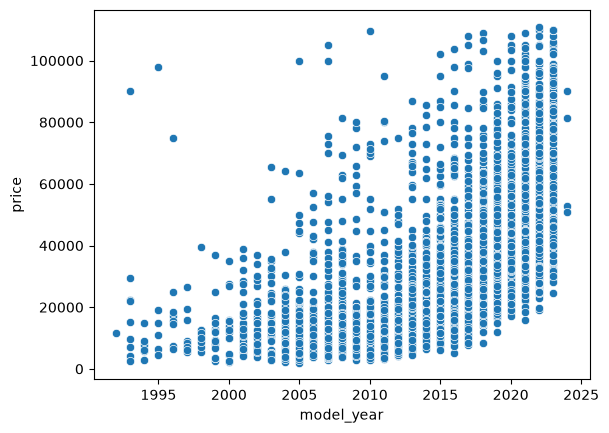

In [25]:
sns.scatterplot(data=df, x='model_year', y='price')
plt.show()

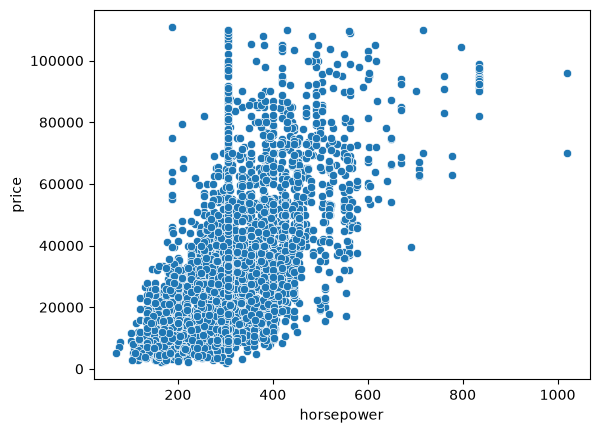

In [26]:
sns.scatterplot(data=df, x='horsepower', y='price')
plt.show()

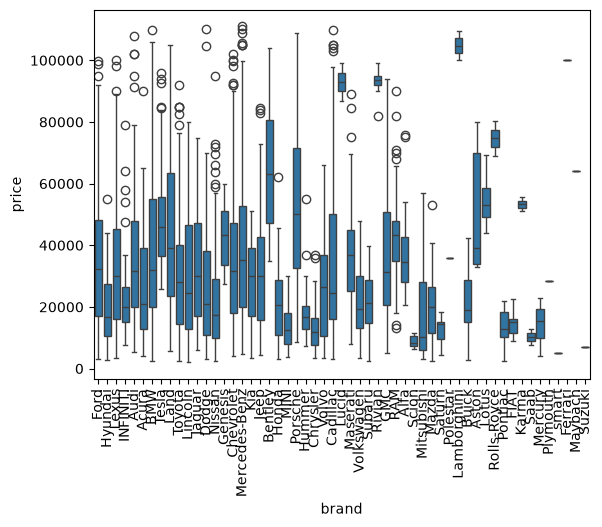

In [27]:
sns.boxplot(data=df, x='brand', y='price')
plt.xticks(rotation=90)
plt.show()

In [28]:
feature_names = pipeline.named_steps['preprocesssor'].get_feature_names_out()

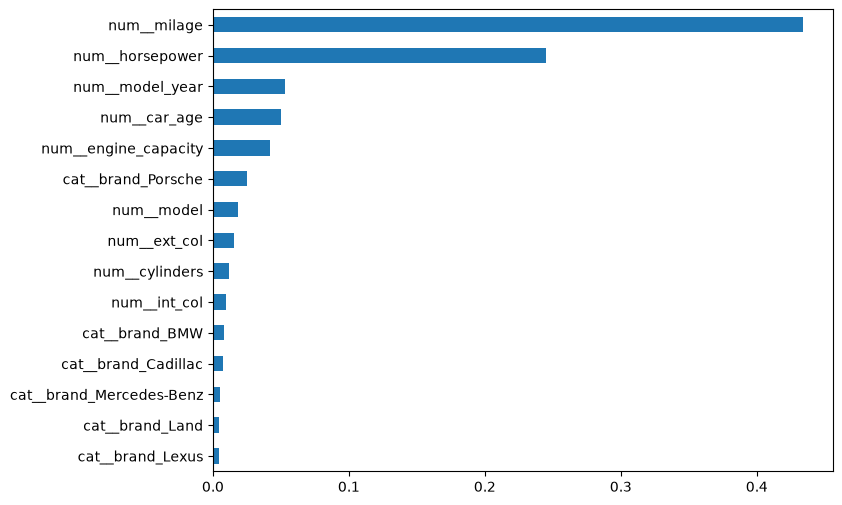

In [29]:
importance = pd.Series(
    pipeline.named_steps['model'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)
importance.head(15).sort_values().plot(kind='barh', figsize=(8,6))
plt.show()